# Gridlock Hackathon 2.0 — Parking Intelligence ML Pipeline v2
**Problem Statement 1:** Poor Visibility on Parking-Induced Congestion

### Cell Order
1. Install dependencies
2. Mount Google Drive + imports
3. Load & clean data
4. Feature engineering
5. EDA charts
6. DBSCAN clustering
7. Build aggregated feature table
8. Model V1 — baseline XGBoost
9. Model V2 — log transform
10. Model V3 — oversampling + weights (FINAL MODEL)
11. Full evaluation report
12. Cross-dataset correlation (bonus)
13. Enforcement calendar generation
14. What-if simulator
15. Export all artifacts

In [ ]:
# ── CELL 1: Install dependencies ──────────────────────────────────────────────
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn folium joblib --quiet
print('Dependencies installed.')

Dependencies installed.


In [ ]:
# ── CELL 2: Mount Google Drive + imports ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/gridlock_hackathon/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')

import pandas as pd
import numpy as np
import ast
import json
import warnings
import joblib
import gc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import DBSCAN
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('All imports done.')

Mounted at /content/drive
Save directory: /content/drive/MyDrive/gridlock_hackathon/
All imports done.


In [ ]:
# ── CELL 3: Load & clean data ─────────────────────────────────────────────────
# Upload CSVs in Colab via Files panel on the left, then set paths below
P1_PATH = 'jan_to_may_police_violation_anonymized.csv'   # ← change if needed
P2_PATH = 'Astram_event_data_anonymized.csv'              # ← for correlation bonus

df = pd.read_csv(P1_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Parse datetimes
df['created_dt'] = pd.to_datetime(df['created_datetime'], utc=True, errors='coerce')
df['hour']        = df['created_dt'].dt.hour
df['day_of_week'] = df['created_dt'].dt.dayofweek   # 0=Mon, 6=Sun
df['day_name']    = df['created_dt'].dt.day_name()
df['month']       = df['created_dt'].dt.month
df['date']        = df['created_dt'].dt.date

# Drop heavy columns we don't need to free memory
df.drop(columns=[
    'vehicle_number', 'updated_vehicle_number', 'updated_vehicle_type',
    'device_id', 'created_by_id', 'modified_datetime',
    'data_sent_to_scita_timestamp', 'action_taken_timestamp',
    'validation_timestamp', 'closed_datetime'
], errors='ignore', inplace=True)
gc.collect()

print(f'After cleanup: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 166,423 rows × 24 columns
After cleanup: 166,423 rows × 20 columns


In [ ]:
# ── CELL 4: Feature engineering ───────────────────────────────────────────────

# Parse violation_type JSON arrays
def extract_violations(v):
    try:
        return ast.literal_eval(v)
    except:
        return []

df['violations_list'] = df['violation_type'].apply(extract_violations)
df['violation_count'] = df['violations_list'].apply(len)

# Vehicle grouping
TWO_WHEELER  = {'SCOOTER', 'MOTOR CYCLE', 'MOPED'}
FOUR_WHEELER = {'CAR', 'JEEP', 'VAN'}
COMMERCIAL   = {'PASSENGER AUTO', 'GOODS AUTO', 'MAXI-CAB', 'TEMPO',
                'LGV', 'HGV', 'LORRY/GOODS VEHICLE', 'MINI LORRY', 'TANKER'}
BUS          = {'PRIVATE BUS', 'BUS (BMTC/KSRTC)', 'TOURIST BUS',
                'SCHOOL VEHICLE', 'FACTORY BUS', 'TRACTOR'}

def veh_group(v):
    if v in TWO_WHEELER:  return 'two_wheeler'
    if v in FOUR_WHEELER: return 'four_wheeler'
    if v in COMMERCIAL:   return 'commercial'
    if v in BUS:          return 'bus'
    return 'other'

df['vehicle_group'] = df['vehicle_type'].apply(veh_group)

# Severity flags from violation types
df['on_main_road']  = df['violations_list'].apply(
    lambda v: int(any('MAIN ROAD' in x for x in v)))
df['on_footpath']   = df['violations_list'].apply(
    lambda v: int(any('FOOTPATH' in x for x in v)))
df['near_junction'] = df['violations_list'].apply(
    lambda v: int(any('CROSSING' in x or 'TRAFFIC LIGHT' in x or 'ZEBRA' in x for x in v)))

print('Feature engineering done.')
print(df[['hour','day_name','vehicle_group','violation_count','on_main_road']].head(3))

Feature engineering done.
   hour day_name vehicle_group  violation_count  on_main_road
0   0.0   Monday  four_wheeler                2             0
1  22.0   Friday  four_wheeler                1             0
2   0.0   Monday  four_wheeler                2             1


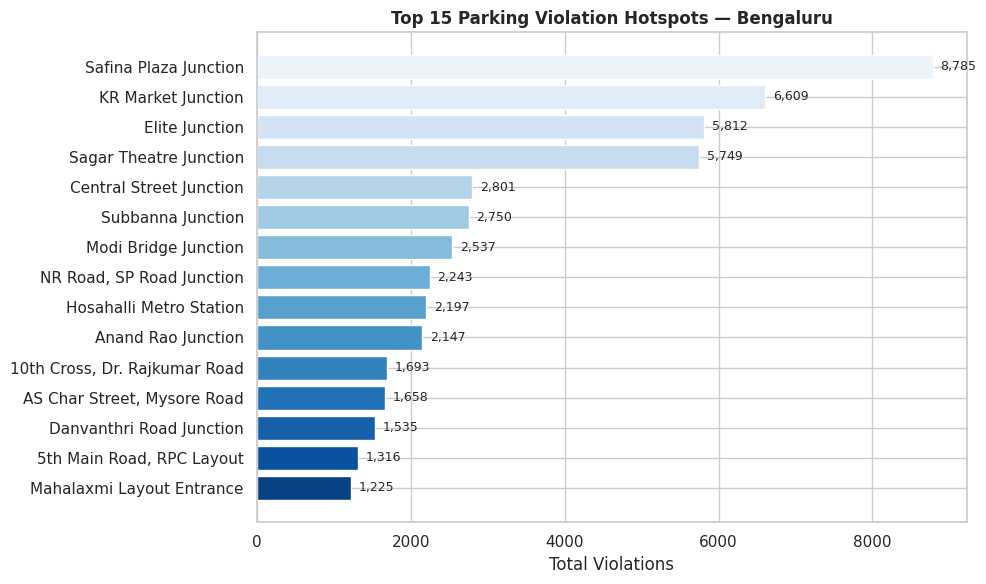

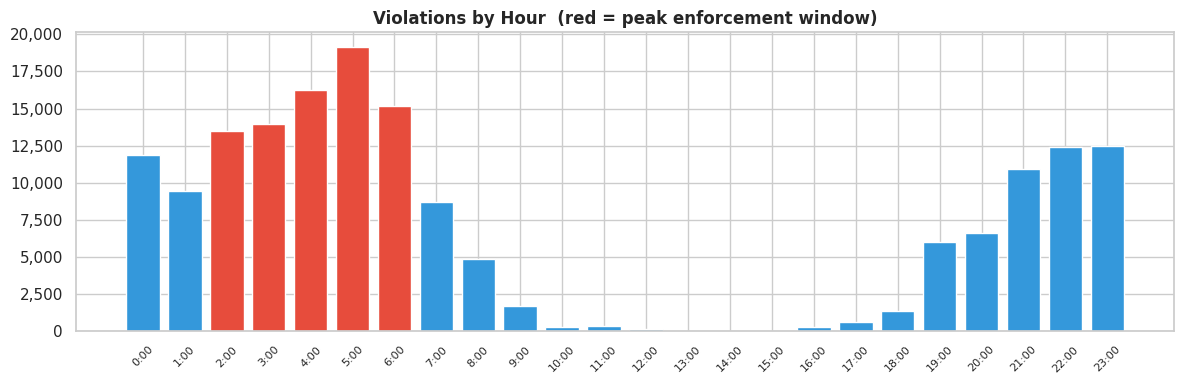

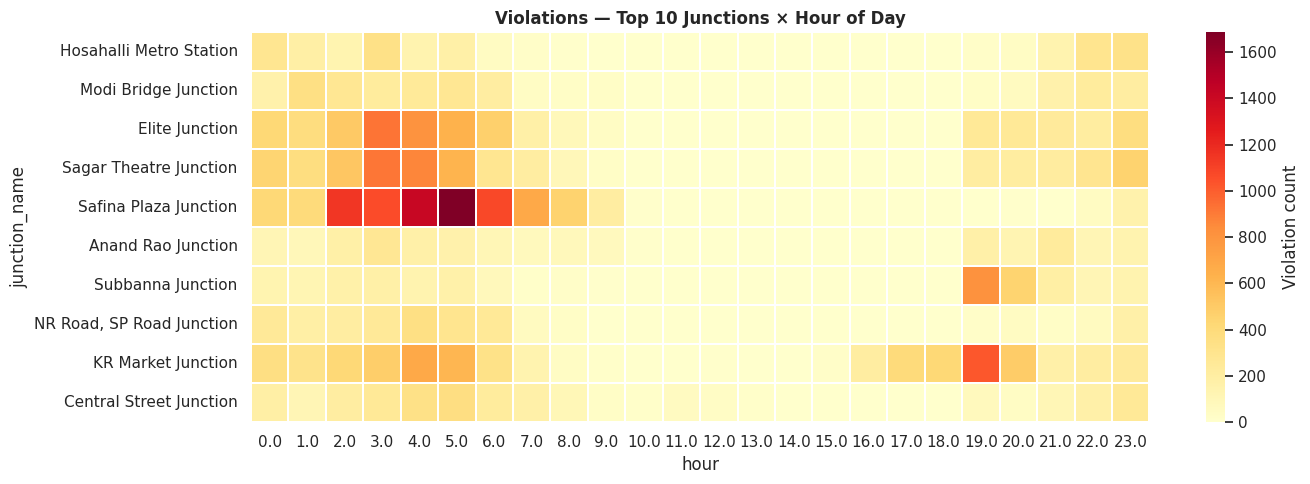

EDA charts saved to Drive.


In [ ]:
# ── CELL 5: EDA charts ────────────────────────────────────────────────────────

# Top 15 hotspot junctions
top_junctions = (
    df[df['junction_name'] != 'No Junction']
    .groupby('junction_name')['id'].count()
    .sort_values(ascending=False)
    .head(15)
)
top_junctions.index = top_junctions.index.str.replace(r'^BTP\d+ - ', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_junctions.index[::-1], top_junctions.values[::-1],
        color=sns.color_palette('Blues_r', 15))
ax.set_xlabel('Total Violations')
ax.set_title('Top 15 Parking Violation Hotspots — Bengaluru', fontweight='bold')
for i, (bar, val) in enumerate(zip(ax.patches, top_junctions.values[::-1])):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'chart_top_junctions.png', dpi=150, bbox_inches='tight')
plt.show()

# Violations by hour
hourly = df.groupby('hour')['id'].count()
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if h in [2,3,4,5,6] else '#3498db' for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=colors, edgecolor='white')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, fontsize=8)
ax.set_title('Violations by Hour  (red = peak enforcement window)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(SAVE_DIR + 'chart_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

# Junction x hour heatmap
top10_names = (
    df[df['junction_name'] != 'No Junction']
    .groupby('junction_name')['id'].count()
    .nlargest(10).index.tolist()
)
pivot = (
    df[df['junction_name'].isin(top10_names)]
    .groupby(['junction_name','hour'])['id'].count()
    .unstack(fill_value=0)
)
pivot.index = pivot.index.str.replace(r'^BTP\d+ - ', '', regex=True)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Violation count'})
ax.set_title('Violations — Top 10 Junctions × Hour of Day', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'chart_heatmap_junction_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print('EDA charts saved to Drive.')

In [ ]:
# ── CELL 6: DBSCAN clustering ─────────────────────────────────────────────────
import psutil
ram = psutil.virtual_memory()
print(f'Available RAM: {ram.available / 1024**3:.1f} GB')

# Free memory before DBSCAN
gc.collect()

sample = df[['latitude','longitude']].dropna().sample(
    n=min(20000, len(df)), random_state=42
).reset_index(drop=True)

coords_rad = np.radians(sample[['latitude','longitude']].values)
db = DBSCAN(eps=0.003, min_samples=30, algorithm='ball_tree', metric='haversine')
labels = db.fit_predict(coords_rad)
sample = sample.copy()
sample['cluster'] = labels

# Free memory immediately
del coords_rad, db, labels
gc.collect()

n_clusters = len(set(sample['cluster'].unique()) - {-1})
n_noise    = (sample['cluster'] == -1).sum()
print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise:,} ({n_noise/len(sample)*100:.1f}%)')

cluster_summary = (
    sample[sample['cluster'] >= 0]
    .groupby('cluster')
    .agg(
        count=('latitude','count'),
        center_lat=('latitude','mean'),
        center_lon=('longitude','mean')
    )
    .sort_values('count', ascending=False)
    .reset_index()
)
print('\nTop 10 hotspot zones:')
print(cluster_summary.head(10).to_string(index=False))

cluster_summary.to_csv(SAVE_DIR + 'hotspot_clusters.csv', index=False)
print('\nSaved: hotspot_clusters.csv')

Available RAM: 10.8 GB
Clusters found : 1
Noise points   : 0 (0.0%)

Top 10 hotspot zones:
 cluster  count  center_lat  center_lon
       0  20000   12.980796   77.599522

Saved: hotspot_clusters.csv


In [ ]:
# ── CELL 7: Build aggregated feature table ────────────────────────────────────
jdf = df[df['junction_name'] != 'No Junction'].copy()

agg = jdf.groupby(['junction_name','hour','day_of_week']).agg(
    total_violations  = ('id', 'count'),
    avg_viol_count    = ('violation_count', 'mean'),
    main_road_pct     = ('on_main_road', 'mean'),
    footpath_pct      = ('on_footpath', 'mean'),
    near_junction_pct = ('near_junction', 'mean'),
    two_wheeler_pct   = ('vehicle_group', lambda x: (x == 'two_wheeler').mean()),
    four_wheeler_pct  = ('vehicle_group', lambda x: (x == 'four_wheeler').mean()),
    commercial_pct    = ('vehicle_group', lambda x: (x == 'commercial').mean()),
).reset_index()

# Severity score (target)
agg['severity_score'] = (
    agg['total_violations'] * 1.0
    + agg['total_violations'] * agg['main_road_pct'] * 0.5
    + agg['total_violations'] * agg['near_junction_pct'] * 0.3
    + agg['total_violations'] * agg['avg_viol_count'] * 0.2
).round(2)

# Encode junctions
le = LabelEncoder()
agg['junction_encoded'] = le.fit_transform(agg['junction_name'])

# Time features
agg['is_weekend']  = (agg['day_of_week'] >= 5).astype(int)

def hour_bucket(h):
    if 0 <= h <= 6:   return 2
    if 19 <= h <= 23: return 1
    return 0

agg['peak_bucket'] = agg['hour'].apply(hour_bucket)

# Historical peak flag
junction_hour_rank = (
    agg.groupby(['junction_name','hour'])['total_violations']
    .mean().reset_index()
)
junction_hour_rank['is_historic_peak'] = (
    junction_hour_rank['total_violations'] >=
    junction_hour_rank['total_violations'].quantile(0.9)
).astype(int)
agg = agg.merge(
    junction_hour_rank[['junction_name','hour','is_historic_peak']],
    on=['junction_name','hour'], how='left'
)

FEATURES = [
    'junction_encoded', 'hour', 'day_of_week', 'is_weekend',
    'peak_bucket', 'is_historic_peak',
    'main_road_pct', 'footpath_pct', 'near_junction_pct',
    'two_wheeler_pct', 'four_wheeler_pct', 'commercial_pct',
    'avg_viol_count',
]

print(f'Feature table: {agg.shape}')
print(f'Severity range: {agg["severity_score"].min():.1f} – {agg["severity_score"].max():.1f}')
print(f'Features: {FEATURES}')

Feature table: (7734, 16)
Severity range: 1.2 – 482.3
Features: ['junction_encoded', 'hour', 'day_of_week', 'is_weekend', 'peak_bucket', 'is_historic_peak', 'main_road_pct', 'footpath_pct', 'near_junction_pct', 'two_wheeler_pct', 'four_wheeler_pct', 'commercial_pct', 'avg_viol_count']


In [ ]:
# ── CELL 8: Model V1 — baseline XGBoost ──────────────────────────────────────
# Quick baseline to compare against V3

X = agg[FEATURES]
y = agg['severity_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_v1 = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
model_v1.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred_v1 = model_v1.predict(X_test)
print(f'V1 — R²: {r2_score(y_test, y_pred_v1):.4f}  |  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v1)):.2f}')

[0]	validation_0-rmse:24.44659
[50]	validation_0-rmse:14.27597
[100]	validation_0-rmse:13.55532
[150]	validation_0-rmse:13.37594
[200]	validation_0-rmse:13.18510
[250]	validation_0-rmse:13.07057
[299]	validation_0-rmse:13.07543
V1 — R²: 0.7317  |  RMSE: 13.08


In [ ]:
# ── CELL 9: Model V2 — log transform ─────────────────────────────────────────

y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
_, _, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_v2 = XGBRegressor(
    n_estimators=400, learning_rate=0.04, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)
model_v2.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)], verbose=50
)

y_pred_v2 = np.expm1(model_v2.predict(X_test))
print(f'V2 — R²: {r2_score(y_test_orig, y_pred_v2):.4f}  |  RMSE: {np.sqrt(mean_squared_error(y_test_orig, y_pred_v2)):.2f}')

[0]	validation_0-rmse:1.03356
[50]	validation_0-rmse:0.49747
[100]	validation_0-rmse:0.45531
[150]	validation_0-rmse:0.44709
[200]	validation_0-rmse:0.44343
[250]	validation_0-rmse:0.44162
[300]	validation_0-rmse:0.44083
[350]	validation_0-rmse:0.44147
[399]	validation_0-rmse:0.44167
V2 — R²: 0.6919  |  RMSE: 14.01


In [ ]:
# ── CELL 10: Model V3 — oversampling + sample weights (FINAL MODEL) ───────────

LOW    = agg[agg['severity_score'] < 50]
MEDIUM = agg[(agg['severity_score'] >= 50) & (agg['severity_score'] < 200)]
HIGH   = agg[agg['severity_score'] >= 200]

print(f'Before balancing — Low: {len(LOW)}, Medium: {len(MEDIUM)}, High: {len(HIGH)}')

MEDIUM_up = pd.concat([MEDIUM] * 3, ignore_index=True)
HIGH_up   = pd.concat([HIGH]   * 8, ignore_index=True)
agg_balanced = pd.concat([LOW, MEDIUM_up, HIGH_up], ignore_index=True)
print(f'After balancing  — Total: {len(agg_balanced):,} rows')

def compute_weights(y):
    weights = np.ones(len(y))
    weights[y >= 50]  = 3.0
    weights[y >= 200] = 8.0
    return weights

y_balanced     = agg_balanced['severity_score']
X_balanced     = agg_balanced[FEATURES]
y_balanced_log = np.log1p(y_balanced)
sample_weights = compute_weights(y_balanced.values)

X_train_b, X_test_b, y_train_b, y_test_b, w_train, _ = train_test_split(
    X_balanced, y_balanced_log, sample_weights,
    test_size=0.2, random_state=42
)
_, _, y_train_orig_b, y_test_orig_b = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

model_v3 = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
    reg_alpha=0.05, reg_lambda=0.5,
    random_state=42, n_jobs=-1, verbosity=0
)
model_v3.fit(
    X_train_b, y_train_b,
    sample_weight=w_train,
    eval_set=[(X_test_b, y_test_b)],
    verbose=50
)

y_pred_v3    = np.expm1(model_v3.predict(X_test_b))
y_true_v3    = y_test_orig_b.values

rmse = np.sqrt(mean_squared_error(y_true_v3, y_pred_v3))
r2   = r2_score(y_true_v3, y_pred_v3)
mae  = mean_absolute_error(y_true_v3, y_pred_v3)

print(f'\n=== Model V3 Performance ===')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')

df_eval_v3 = pd.DataFrame({'actual': y_true_v3, 'predicted': y_pred_v3})
df_eval_v3['tier'] = pd.cut(
    df_eval_v3['actual'],
    bins=[0, 50, 200, 500, float('inf')],
    labels=['Low (0-50)', 'Medium (50-200)', 'High (200-500)', 'Critical (500+)']
)
print('\nR² by severity tier:')
for tier, grp in df_eval_v3.groupby('tier', observed=True):
    if len(grp) > 5:
        print(f'  {str(tier):<22}: R²={r2_score(grp["actual"], grp["predicted"]):.4f}  (n={len(grp)})')

# Save final model
joblib.dump(model_v3, SAVE_DIR + 'model.pkl')
joblib.dump(le,       SAVE_DIR + 'junction_encoder.pkl')
print('\nSaved: model.pkl + junction_encoder.pkl')

Before balancing — Low: 7322, Medium: 384, High: 28
After balancing  — Total: 8,698 rows
[0]	validation_0-rmse:1.49635
[50]	validation_0-rmse:0.56146
[100]	validation_0-rmse:0.45400
[150]	validation_0-rmse:0.43581
[200]	validation_0-rmse:0.42923
[250]	validation_0-rmse:0.42401
[300]	validation_0-rmse:0.42025
[350]	validation_0-rmse:0.41752
[400]	validation_0-rmse:0.41537
[450]	validation_0-rmse:0.41454
[499]	validation_0-rmse:0.41308

=== Model V3 Performance ===
R²   : 0.9667
RMSE : 9.24
MAE  : 4.43

R² by severity tier:
  Low (0-50)            : R²=0.4746  (n=1449)
  Medium (50-200)       : R²=0.7530  (n=243)
  High (200-500)        : R²=0.9828  (n=48)

Saved: model.pkl + junction_encoder.pkl


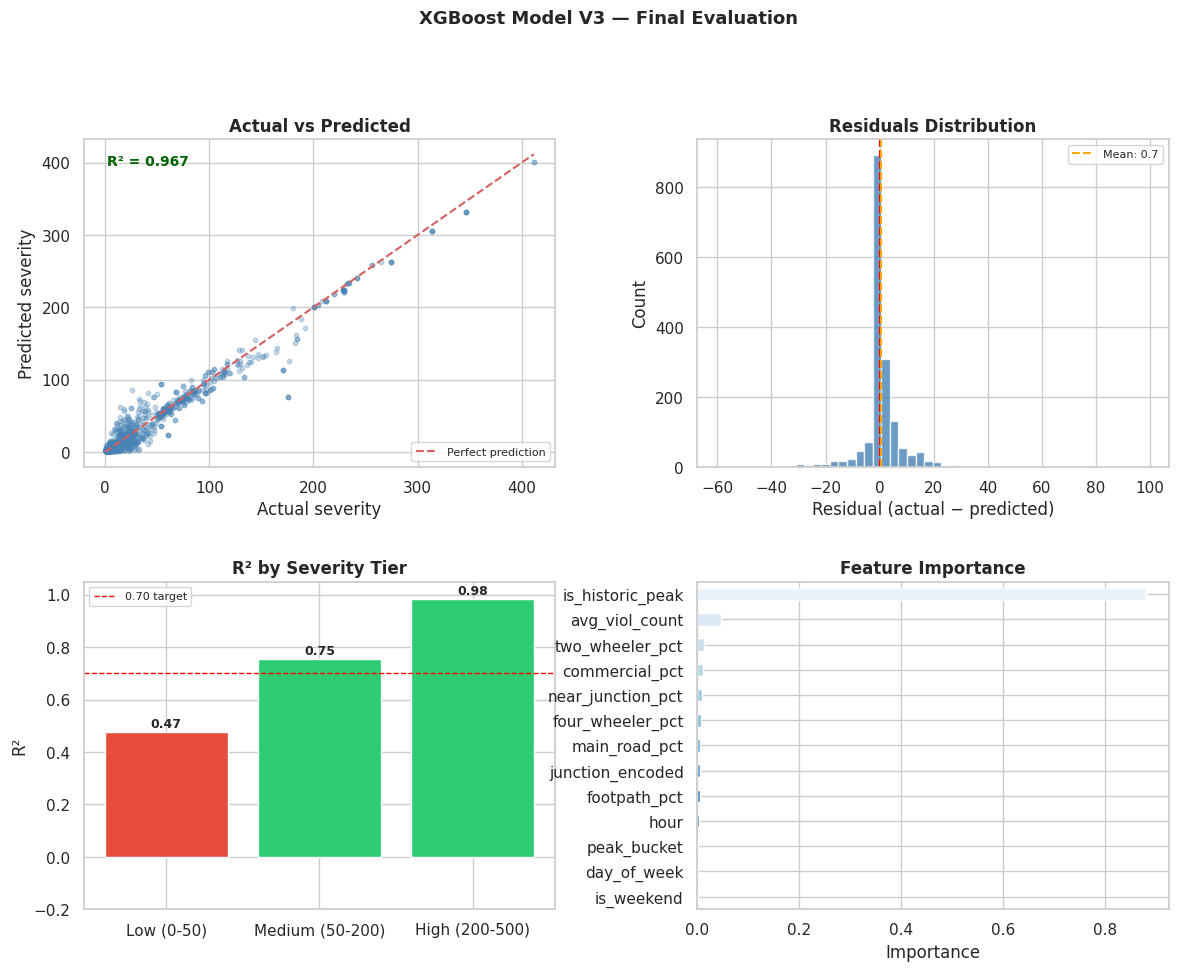

Saved: chart_model_evaluation.png


In [ ]:
# ── CELL 11: Full evaluation report (4 charts) ────────────────────────────────

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Chart 1: Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_true_v3, y_pred_v3, alpha=0.3, s=10, color='steelblue')
lims = [0, max(y_true_v3.max(), y_pred_v3.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual severity')
ax1.set_ylabel('Predicted severity')
ax1.set_title('Actual vs Predicted', fontweight='bold')
ax1.legend(fontsize=8)
ax1.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax1.transAxes,
         fontsize=10, color='darkgreen', fontweight='bold')

# Chart 2: Residuals
ax2 = fig.add_subplot(gs[0, 1])
residuals = y_true_v3 - y_pred_v3
ax2.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.axvline(residuals.mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Mean: {residuals.mean():.1f}')
ax2.set_xlabel('Residual (actual − predicted)')
ax2.set_ylabel('Count')
ax2.set_title('Residuals Distribution', fontweight='bold')
ax2.legend(fontsize=8)

# Chart 3: R² by tier
ax3 = fig.add_subplot(gs[1, 0])
tier_r2 = {}
for tier, grp in df_eval_v3.groupby('tier', observed=True):
    if len(grp) > 5:
        tier_r2[str(tier)] = r2_score(grp['actual'], grp['predicted'])
colors = ['#2ecc71' if v >= 0.70 else '#e74c3c' for v in tier_r2.values()]
ax3.bar(tier_r2.keys(), tier_r2.values(), color=colors, edgecolor='white')
ax3.axhline(0.70, color='red', linestyle='--', linewidth=1, label='0.70 target')
ax3.set_ylabel('R²')
ax3.set_title('R² by Severity Tier', fontweight='bold')
ax3.set_ylim(-0.2, 1.05)
ax3.legend(fontsize=8)
for i, (k, v) in enumerate(tier_r2.items()):
    ax3.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Chart 4: Feature importance
ax4 = fig.add_subplot(gs[1, 1])
fi = pd.Series(model_v3.feature_importances_, index=FEATURES).sort_values()
fi.plot(kind='barh', ax=ax4, color=sns.color_palette('Blues_r', len(fi)))
ax4.set_title('Feature Importance', fontweight='bold')
ax4.set_xlabel('Importance')

plt.suptitle('XGBoost Model V3 — Final Evaluation', fontsize=13,
             fontweight='bold', y=1.01)
plt.savefig(SAVE_DIR + 'chart_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_model_evaluation.png')

Event days found: 79
Avg violations — Normal days : 1098
Avg violations — Event days  : 1092
Spike during events          : +-0.5%


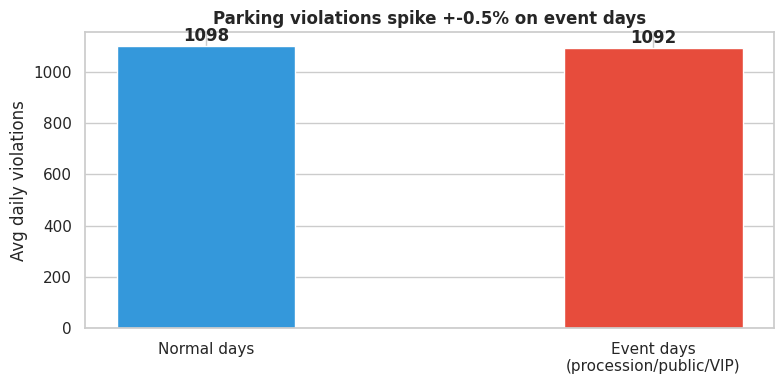

Saved: chart_event_correlation.png


In [ ]:
# ── CELL 12: Cross-dataset correlation (bonus differentiator) ─────────────────

try:
    df2 = pd.read_csv(P2_PATH)
    df2['start_dt'] = pd.to_datetime(df2['start_datetime'], utc=True, errors='coerce')
    df2['date']     = df2['start_dt'].dt.date

    EVENT_CAUSES = ['public_event', 'procession', 'vip_movement', 'protest']
    event_days   = set(df2[df2['event_cause'].isin(EVENT_CAUSES)]['date'].dropna())
    print(f'Event days found: {len(event_days)}')

    daily = df.groupby('date')['id'].count().reset_index()
    daily.columns = ['date', 'violation_count']
    daily['is_event_day'] = daily['date'].isin(event_days)

    event_avg  = daily[daily['is_event_day']]['violation_count'].mean()
    normal_avg = daily[~daily['is_event_day']]['violation_count'].mean()
    spike_pct  = ((event_avg - normal_avg) / normal_avg) * 100

    print(f'Avg violations — Normal days : {normal_avg:.0f}')
    print(f'Avg violations — Event days  : {event_avg:.0f}')
    print(f'Spike during events          : +{spike_pct:.1f}%')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(['Normal days', 'Event days\n(procession/public/VIP)'],
           [normal_avg, event_avg],
           color=['#3498db', '#e74c3c'], width=0.4)
    ax.set_ylabel('Avg daily violations')
    ax.set_title(f'Parking violations spike +{spike_pct:.1f}% on event days',
                 fontweight='bold')
    for i, v in enumerate([normal_avg, event_avg]):
        ax.text(i, v + 20, f'{v:.0f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'chart_event_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: chart_event_correlation.png')

except FileNotFoundError:
    print('P2 CSV not found — skipping correlation. Upload it to use this section.')

Prediction grid: 28,224 rows

Top 10 highest severity slots:
                        junction_name  day_name  hour  predicted_severity  recommended_officers
BTP189 - New Diagonal Road, Jayanagar    Friday    23           68.360001                     1
BTP189 - New Diagonal Road, Jayanagar  Saturday    23           68.019997                     1
BTP189 - New Diagonal Road, Jayanagar    Sunday    23           64.339996                     1
BTP189 - New Diagonal Road, Jayanagar  Saturday    19           62.610001                     1
BTP189 - New Diagonal Road, Jayanagar  Saturday     3           61.599998                     1
BTP189 - New Diagonal Road, Jayanagar  Saturday     5           61.549999                     1
BTP189 - New Diagonal Road, Jayanagar  Saturday    17           61.480000                     1
BTP189 - New Diagonal Road, Jayanagar  Saturday     2           61.410000                     1
BTP189 - New Diagonal Road, Jayanagar Wednesday     2           61.360001  

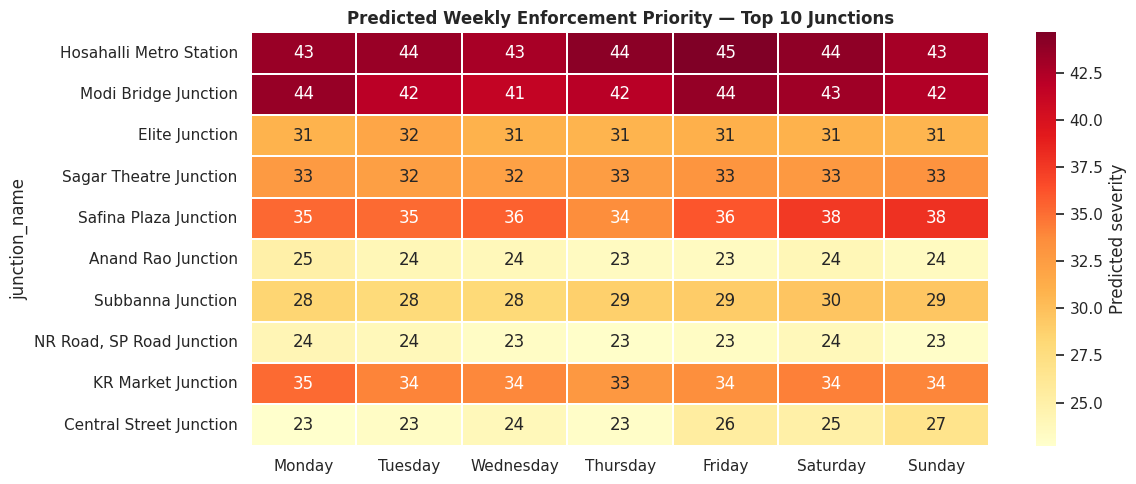

Saved: enforcement_predictions.csv + chart_enforcement_calendar.png


In [ ]:
# ── CELL 13: Enforcement calendar generation ──────────────────────────────────

DAY_NAMES = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
junctions = agg['junction_name'].unique()

# Build full prediction grid
rows = []
for jname in junctions:
    j_enc  = le.transform([jname])[0]
    j_data = agg[agg['junction_name'] == jname]
    avg_feats = j_data[[
        'main_road_pct','footpath_pct','near_junction_pct',
        'two_wheeler_pct','four_wheeler_pct','commercial_pct',
        'avg_viol_count','is_historic_peak'
    ]].mean()

    for d in range(7):
        for h in range(24):
            rows.append({
                'junction_name':    jname,
                'junction_encoded': j_enc,
                'hour':             h,
                'day_of_week':      d,
                'is_weekend':       int(d >= 5),
                'peak_bucket':      hour_bucket(h),
                **avg_feats.to_dict()
            })

grid = pd.DataFrame(rows)

# Predict with model_v3 + inverse log transform
grid['predicted_severity'] = np.expm1(
    model_v3.predict(grid[FEATURES])
).round(2)

# Officer recommendation: 1 per 200 predicted violations, capped at 5
grid['recommended_officers'] = (grid['predicted_severity'] / 200).apply(
    lambda x: max(1, min(5, round(x)))
)
grid['day_name'] = grid['day_of_week'].apply(lambda x: DAY_NAMES[x])

print(f'Prediction grid: {len(grid):,} rows')
print('\nTop 10 highest severity slots:')
print(
    grid.nlargest(10, 'predicted_severity')[
        ['junction_name','day_name','hour','predicted_severity','recommended_officers']
    ].to_string(index=False)
)

# Weekly enforcement calendar heatmap
top10_names = (
    df[df['junction_name'] != 'No Junction']
    .groupby('junction_name')['id'].count()
    .nlargest(10).index.tolist()
)
calendar = (
    grid[grid['junction_name'].isin(top10_names)]
    .groupby(['junction_name','day_of_week'])['predicted_severity']
    .max().unstack()
)
calendar.columns = DAY_NAMES
calendar.index   = calendar.index.str.replace(r'^BTP\d+ - ', '', regex=True)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(calendar, cmap='YlOrRd', ax=ax, fmt='.0f', annot=True,
            linewidths=0.3, cbar_kws={'label': 'Predicted severity'})
ax.set_title('Predicted Weekly Enforcement Priority — Top 10 Junctions',
             fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'chart_enforcement_calendar.png', dpi=150, bbox_inches='tight')
plt.show()

grid.to_csv(SAVE_DIR + 'enforcement_predictions.csv', index=False)
print('Saved: enforcement_predictions.csv + chart_enforcement_calendar.png')

In [ ]:
# ── CELL 14: What-if simulator ────────────────────────────────────────────────

EVENT_MULTIPLIERS = {
    'public_event':  1.35,
    'procession':    1.28,
    'vip_movement':  1.20,
    'protest':       1.15,
    'construction':  1.10,
    'none':          1.00,
}

# Junction lat/lon lookup
junction_coords = (
    df[df['junction_name'] != 'No Junction']
    .groupby('junction_name')
    .agg(lat=('latitude','mean'), lon=('longitude','mean'))
    .reset_index()
)

def simulate(event_type: str, hour: int, day_of_week: int, top_n: int = 10):
    """
    Simulate enforcement needs for a given event type + time.

    Args:
        event_type  : one of EVENT_MULTIPLIERS keys
        hour        : 0–23
        day_of_week : 0=Mon, 6=Sun
        top_n       : junctions to return

    Returns:
        DataFrame ranked by adjusted severity
    """
    multiplier = EVENT_MULTIPLIERS.get(event_type, 1.0)
    subset = grid[
        (grid['hour'] == hour) & (grid['day_of_week'] == day_of_week)
    ].copy()

    subset['adjusted_severity']    = (subset['predicted_severity'] * multiplier).round(2)
    subset['recommended_officers'] = (subset['adjusted_severity'] / 200).apply(
        lambda x: max(1, min(5, round(x)))
    )
    subset['event_type']  = event_type
    subset['day_name_str'] = DAY_NAMES[day_of_week]

    return (
        subset
        .nlargest(top_n, 'adjusted_severity')
        [['junction_name','day_name_str','hour',
          'adjusted_severity','recommended_officers','event_type']]
        .merge(junction_coords, on='junction_name', how='left')
        .reset_index(drop=True)
        .rename(index=lambda x: x + 1)  # rank from 1
    )

# Test
print('=== Test: Sunday 9 PM with public event ===')
result = simulate('public_event', hour=21, day_of_week=6)
print(result[['junction_name','adjusted_severity','recommended_officers']].to_string())

print('\n=== Test: Monday 5 AM — no event ===')
result2 = simulate('none', hour=5, day_of_week=0)
print(result2[['junction_name','adjusted_severity','recommended_officers']].to_string())

=== Test: Sunday 9 PM with public event ===
                               junction_name  adjusted_severity  recommended_officers
1      BTP189 - New Diagonal Road, Jayanagar          72.580002                     1
2                 BTP184 - Lalbagh West Gate          70.669998                     1
3   BTP182 - 19th Main Junction, Rajajinagar          65.919998                     1
4    BTP186 - 9th Cross, 4th Main, Jayanagar          62.549999                     1
5           BTP218 - Syndicate Bank Junction          59.119999                     1
6                 BTP043 - Upparpet Junction          58.779999                     1
7                 BTP220 - Puttanna Junction          56.880001                     1
8        BTP109 - Dewan Madhava Rao Junction          56.540001                     1
9                BTP078 - NR Square Junction          53.930000                     1
10                 BTP216 - Yediyur Junction          53.639999                     1

=== Test:

In [ ]:
# ── CELL 15: Export all artifacts ─────────────────────────────────────────────

# Junction metadata
junction_meta = (
    df[df['junction_name'] != 'No Junction']
    .groupby('junction_name')
    .agg(
        total_violations = ('id', 'count'),
        lat              = ('latitude', 'mean'),
        lon              = ('longitude', 'mean'),
        peak_hour        = ('hour', lambda x: x.value_counts().idxmax()),
        top_vehicle      = ('vehicle_type', lambda x: x.value_counts().idxmax()),
        main_road_pct    = ('on_main_road', 'mean'),
    )
    .reset_index()
    .sort_values('total_violations', ascending=False)
)
junction_meta.to_csv(SAVE_DIR + 'junction_metadata.csv', index=False)

# Hourly stats for frontend time slider
hourly_stats = (
    df[df['junction_name'] != 'No Junction']
    .groupby(['junction_name','hour'])
    .agg(
        violation_count = ('id', 'count'),
        lat             = ('latitude', 'mean'),
        lon             = ('longitude', 'mean'),
    )
    .reset_index()
)
hourly_stats.to_csv(SAVE_DIR + 'hourly_junction_stats.csv', index=False)

# Save feature list so backend uses the same ones
import json
with open(SAVE_DIR + 'features.json', 'w') as f:
    json.dump(FEATURES, f)

# Save event multipliers for simulator endpoint
with open(SAVE_DIR + 'event_multipliers.json', 'w') as f:
    json.dump(EVENT_MULTIPLIERS, f)

# Folium heatmap
import folium
from folium.plugins import HeatMap

map_sample = df[['latitude','longitude']].dropna().sample(
    n=min(20000, len(df)), random_state=42
)
m = folium.Map(location=[12.9716, 77.5946], zoom_start=12,
               tiles='CartoDB dark_matter')
HeatMap(
    map_sample[['latitude','longitude']].values.tolist(),
    radius=8, blur=10,
    gradient={0.2:'blue', 0.5:'yellow', 0.8:'orange', 1.0:'red'}
).add_to(m)
for _, row in junction_meta.head(15).iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8, color='white', fill=True,
        fill_color='red', fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>{row['junction_name']}</b><br>Violations: {row['total_violations']:,}<br>Peak hour: {row['peak_hour']}:00",
            max_width=220
        )
    ).add_to(m)
m.save(SAVE_DIR + 'bengaluru_violation_heatmap.html')

# Summary
print('=== ALL ARTIFACTS SAVED TO GOOGLE DRIVE ===')
files = [
    'model.pkl', 'junction_encoder.pkl', 'features.json',
    'event_multipliers.json', 'enforcement_predictions.csv',
    'junction_metadata.csv', 'hourly_junction_stats.csv',
    'hotspot_clusters.csv', 'bengaluru_violation_heatmap.html',
    'chart_top_junctions.png', 'chart_hourly.png',
    'chart_heatmap_junction_hour.png', 'chart_model_evaluation.png',
    'chart_enforcement_calendar.png', 'chart_event_correlation.png'
]
for f in files:
    path = SAVE_DIR + f
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 if exists else 0
    status = f'{size:.1f} KB' if exists else 'MISSING'
    print(f'  {f:<45} {status}')

print('\nHand off the Drive folder to your backend teammate.')

=== ALL ARTIFACTS SAVED TO GOOGLE DRIVE ===
  model.pkl                                     3347.9 KB
  junction_encoder.pkl                          6.1 KB
  features.json                                 0.2 KB
  event_multipliers.json                        0.1 KB
  enforcement_predictions.csv                   4827.6 KB
  junction_metadata.csv                         16.4 KB
  hourly_junction_stats.csv                     146.5 KB
  hotspot_clusters.csv                          0.1 KB
  bengaluru_violation_heatmap.html              526.5 KB
  chart_top_junctions.png                       118.8 KB
  chart_hourly.png                              51.8 KB
  chart_heatmap_junction_hour.png               97.0 KB
  chart_model_evaluation.png                    200.8 KB
  chart_enforcement_calendar.png                139.7 KB
  chart_event_correlation.png                   43.6 KB

Hand off the Drive folder to your backend teammate.
